In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
from sqlalchemy import create_engine
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_scoreimport osfrom dotenv import load_dotenvload_dotenv()

In [2]:
# Parámetros de conexión
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={os.getenv('DB_SERVER')};"
    "DATABASE=master;"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')};"
)

# Crear engine
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")


# Consulta completa
query = """
SELECT 
    Codigo_Cliente,
    Nombre_Cliente,
    Numero_Documento,
    Fecha_Documento,
    Valor_Subtotal
FROM B2B.dbo.Ventas_B2BMovinova
WHERE 
    Tipo_Cliente = 'HOTEL'
    AND Fecha_Documento >= '2024-10-01'
    AND Fecha_Documento <= '2025-09-30'
"""

df_hoteles = pd.read_sql(query, engine)

df_hoteles['Fecha_Documento'] = pd.to_datetime(df_hoteles['Fecha_Documento'], errors='coerce')

# Resumen rápido
print("Dimensiones (filas, columnas):", df_hoteles.shape)
print("Rango de fechas:", df_hoteles['Fecha_Documento'].min(), "→", df_hoteles['Fecha_Documento'].max())
print("Clientes únicos:", df_hoteles['Codigo_Cliente'].nunique())
print("Facturas únicas:", df_hoteles['Numero_Documento'].nunique())

Dimensiones (filas, columnas): (4632, 5)
Rango de fechas: 2024-10-03 00:00:00 → 2025-09-30 00:00:00
Clientes únicos: 244
Facturas únicas: 1410


In [3]:
# =========================================
# Calcular la tabla de RFM
# =========================================

# Fecha de referencia = última fecha de venta
fecha_ref = df_hoteles["Fecha_Documento"].max()

# Agrupamos por cliente
rfm = df_hoteles.groupby("Codigo_Cliente").agg({
    "Fecha_Documento": lambda x: (fecha_ref - x.max()).days,  # Recency
    "Numero_Documento": "nunique",  # Frequency
    "Valor_Subtotal": "sum"         # Monetary
}).reset_index()

# Renombrar columnas
rfm.columns = ["Codigo_Cliente", "Recency", "Frequency", "Monetary"]

# Vista general
print("Tabla RFM creada correctamente ✅")
print(f"Clientes únicos: {rfm.shape[0]}")
print("\nEstadísticas básicas:")
print(rfm.describe())

Tabla RFM creada correctamente ✅
Clientes únicos: 244

Estadísticas básicas:
          Recency   Frequency      Monetary
count  244.000000  244.000000  2.440000e+02
mean    99.672131    5.778689  1.220383e+07
std     97.848959    9.161570  3.469674e+07
min      0.000000    1.000000  2.346900e+04
25%     22.000000    1.000000  7.937860e+05
50%     61.000000    3.000000  2.491673e+06
75%    161.000000    7.000000  8.576572e+06
max    355.000000  106.000000  3.305660e+08


In [4]:
# =========================================
# Escalar las variables RFM
# =========================================

# Seleccionamos solo las columnas numéricas
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Escalamos
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convertimos a DataFrame escalado
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Variables RFM escaladas correctamente ✅")
rfm_scaled_df.head()

Variables RFM escaladas correctamente ✅


,Recency,Frequency,Monetary
0,-0.191218,-0.413298,-0.322553
1,1.334667,-0.194546,-0.334626
2,0.423232,-0.413298,-0.312250
3,0.781661,-0.522674,-0.301741
4,-0.293627,-0.522674,-0.335651


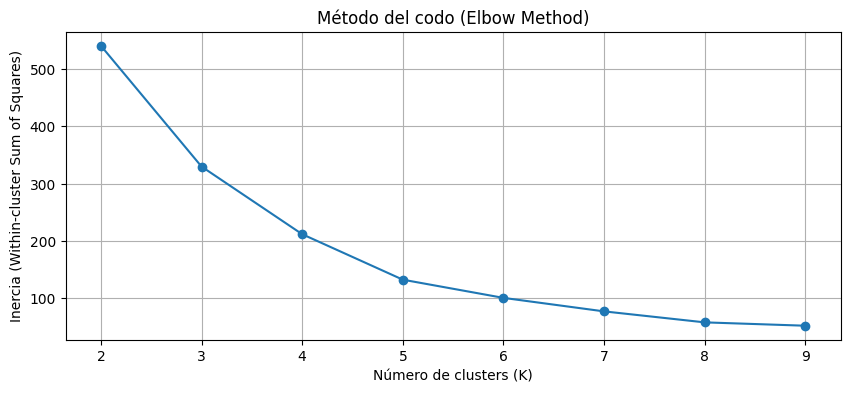

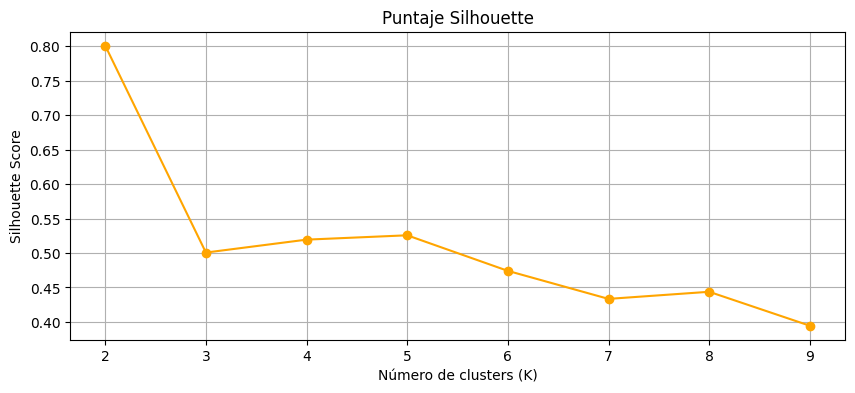

In [5]:
# =========================================
# Determinar el número óptimo de clusters
# =========================================

inertia = []
silhouette = []
K_values = range(2, 10)  

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(rfm_scaled_df, kmeans.labels_))

# --- Gráfico 1: Método del codo ---
plt.figure(figsize=(10,4))
plt.plot(K_values, inertia, marker='o')
plt.title('Método del codo (Elbow Method)')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (Within-cluster Sum of Squares)')
plt.grid(True)
plt.show()

# --- Gráfico 2: Puntaje Silhouette ---
plt.figure(figsize=(10,4))
plt.plot(K_values, silhouette, marker='o', color='orange')
plt.title('Puntaje Silhouette')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [6]:
# =========================================
# Aplicar KMeans con K=4 y crear segmentos
# =========================================

# Aplicar KMeans con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# Promedio de RFM por cluster
rfm_clusters = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Codigo_Cliente': 'count'
}).rename(columns={'Codigo_Cliente': 'NumClientes'}).reset_index()

rfm_clusters

,Cluster,Recency,Frequency,Monetary,NumClientes
0,0,234.605634,1.873239,1.828455e+06,71
1,1,45.353293,6.071856,1.090295e+07,167
2,2,24.333333,20.000000,2.805762e+08,3
3,3,5.333333,67.666667,6.179795e+07,3


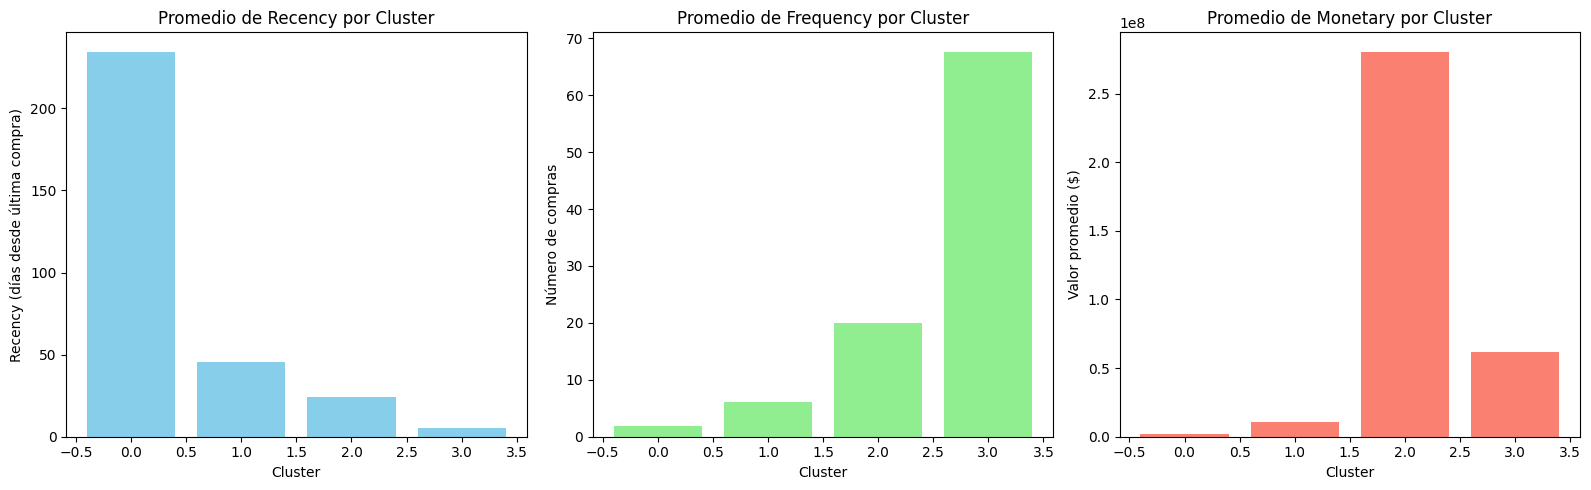

In [7]:
# =========================================
# Visualización de los clusters
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico Recency
axes[0].bar(rfm_clusters['Cluster'], rfm_clusters['Recency'], color='skyblue')
axes[0].set_title('Promedio de Recency por Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Recency (días desde última compra)')

# Gráfico Frequency
axes[1].bar(rfm_clusters['Cluster'], rfm_clusters['Frequency'], color='lightgreen')
axes[1].set_title('Promedio de Frequency por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de compras')

# Gráfico Monetary
axes[2].bar(rfm_clusters['Cluster'], rfm_clusters['Monetary'], color='salmon')
axes[2].set_title('Promedio de Monetary por Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Valor promedio ($)')

plt.tight_layout()
plt.show()


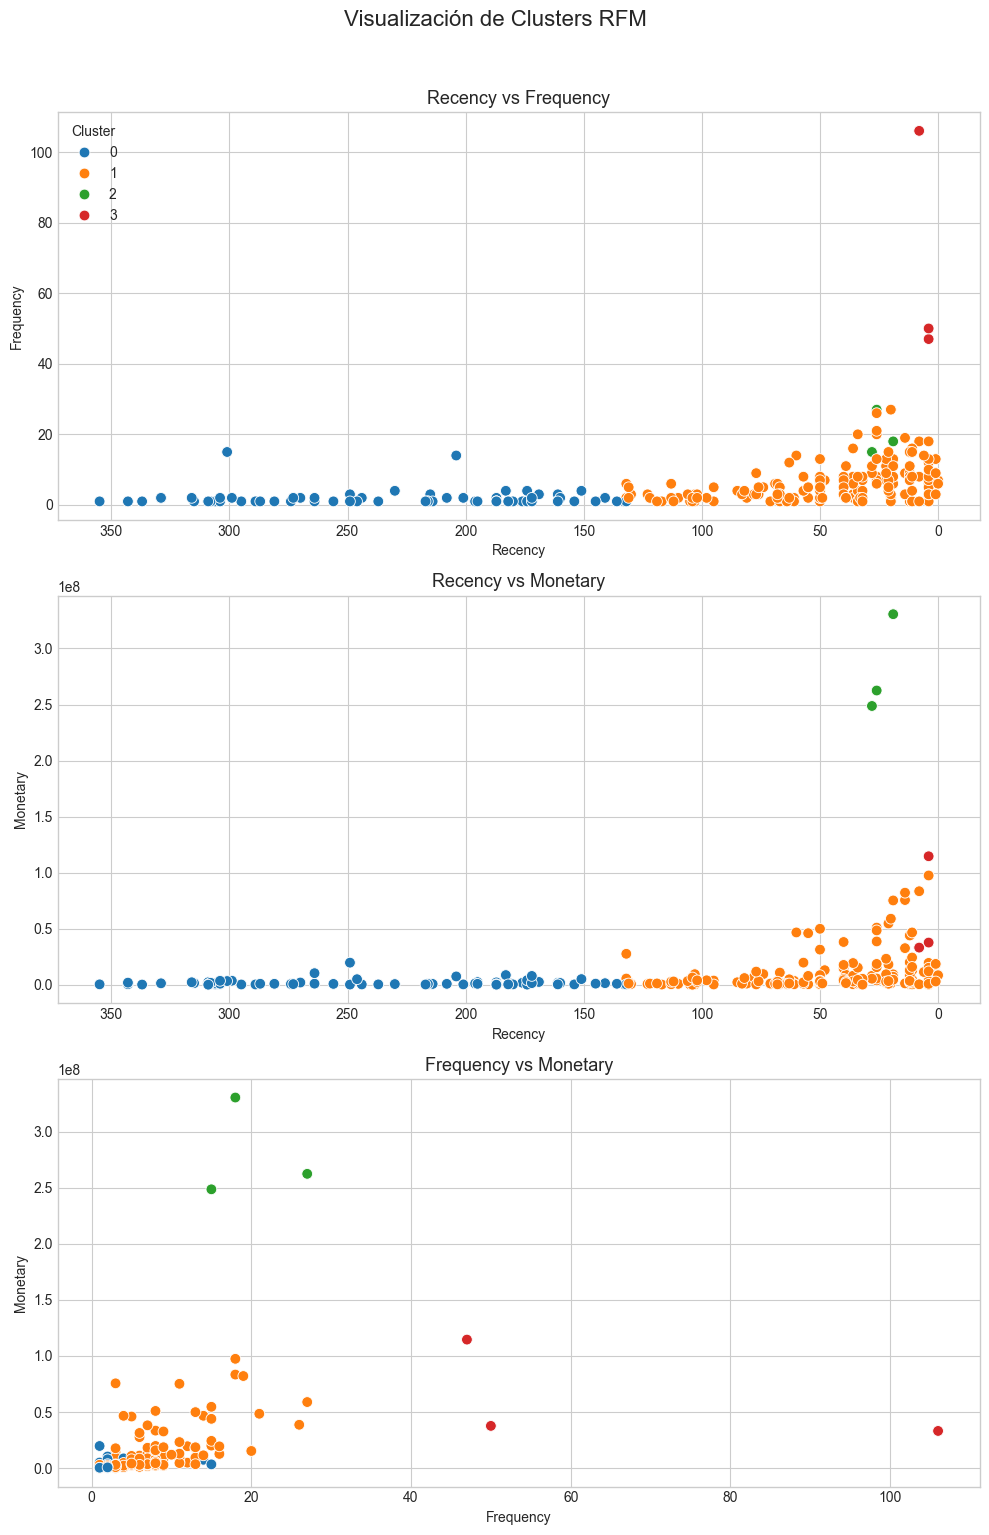

In [10]:
# =========================================
# Visualización de Clusters RFM
# =========================================

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("tab10")

# Crear figura con 3 subplots (uno debajo del otro)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# --- 1️⃣ Recency vs Frequency ---
sns.scatterplot(
    data=rfm,
    x='Recency', y='Frequency',
    hue='Cluster', palette='tab10', s=60, ax=axes[0]
)
axes[0].invert_xaxis()  # menor recency = mejor cliente
axes[0].set_title('Recency vs Frequency', fontsize=13)
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Frequency')

# --- 2️⃣ Recency vs Monetary ---
sns.scatterplot(
    data=rfm,
    x='Recency', y='Monetary',
    hue='Cluster', palette='tab10', s=60, ax=axes[1], legend=False
)
axes[1].invert_xaxis()
axes[1].set_title('Recency vs Monetary', fontsize=13)
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')

# --- 3️⃣ Frequency vs Monetary ---
sns.scatterplot(
    data=rfm,
    x='Frequency', y='Monetary',
    hue='Cluster', palette='tab10', s=60, ax=axes[2], legend=False
)
axes[2].set_title('Frequency vs Monetary', fontsize=13)
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Monetary')

plt.suptitle('Visualización de Clusters RFM', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
def asignar_segmento(row):
    if row['Cluster'] == 3:
        return 'Leales / Recurrentes'
    elif row['Cluster'] == 2:
        return 'High Value / Grandes Compradores'
    elif row['Cluster'] == 1:
        return 'Ocasionales'
    else:
        return 'Dormidos / Inactivos'

rfm['Segmento'] = rfm.apply(asignar_segmento, axis=1)

# Resumen final por segmento
segmento_resumen = rfm.groupby('Segmento').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Codigo_Cliente': 'count'
}).rename(columns={'Codigo_Cliente': 'NumClientes'}).reset_index()

segmento_resumen

,Segmento,Recency,Frequency,Monetary,NumClientes
0,Dormidos / Inactivos,234.605634,1.873239,1.828455e+06,71
1,High Value / Grandes Compradores,24.333333,20.000000,2.805762e+08,3
2,Leales / Recurrentes,5.333333,67.666667,6.179795e+07,3
3,Ocasionales,45.353293,6.071856,1.090295e+07,167
